**STUDENT PERFORMANCE PREDICTION USING ML**

This project predicts student academic performance using machine learning algorithms such as Logistic Regression, Decision Tree, and Random Forest based on student behavior and academic activity data.


In [47]:
## STEP 1 : IMPORT REQUIRED LIBRARIES

# DATA MANIPULATION LIBRARIES
import pandas as pd
import numpy as np

# DATA VISUALIZATION LIBRARIES
import matplotlib.pyplot as plt
import seaborn as sns

# MACHINE LEARNING LIBRARIES
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# MACHINE LEARNING MODELS
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# MODEL EVALUATION METRICS
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# IGNORE WARNINGS
import warnings
warnings.filterwarnings('ignore')

# SET VISUALIZATION STYLE
sns.set_style("whitegrid")
print("Libraries imported successfully!")

Libraries imported successfully!


In [48]:
## STEP 2 : UPLOAD DATASET

from google.colab import files
uploaded = files.upload()

Saving xAPI-Edu-Data.csv to xAPI-Edu-Data.csv


In [49]:
# LOAD DATASET

# Read CSV file
df = pd.read_csv("xAPI-Edu-Data.csv")

# Display first 5 rows
df.head()

,gender,NationalITy,PlaceofBirth,StageID,GradeID,SectionID,Topic,Semester,Relation,raisedhands,VisITedResources,AnnouncementsView,Discussion,ParentAnsweringSurvey,ParentschoolSatisfaction,StudentAbsenceDays,Class
0,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,15,16,2,20,Yes,Good,Under-7,M
1,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,20,20,3,25,Yes,Good,Under-7,M
2,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,10,7,0,30,No,Bad,Above-7,L
3,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,30,25,5,35,No,Bad,Above-7,L
4,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,40,50,12,50,No,Bad,Above-7,M


In [50]:
# CHECK DATASET DIMENSIONS
print("Dataset Shape:", df.shape)

Dataset Shape: (480, 17)


In [51]:
# DISPLAY COLUMN NAMES
print(df.columns)

Index(['gender', 'NationalITy', 'PlaceofBirth', 'StageID', 'GradeID',
       'SectionID', 'Topic', 'Semester', 'Relation', 'raisedhands',
       'VisITedResources', 'AnnouncementsView', 'Discussion',
       'ParentAnsweringSurvey', 'ParentschoolSatisfaction',
       'StudentAbsenceDays', 'Class'],
      dtype='object')


In [52]:
# DATASET INFORMATION
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   gender                    480 non-null    object
 1   NationalITy               480 non-null    object
 2   PlaceofBirth              480 non-null    object
 3   StageID                   480 non-null    object
 4   GradeID                   480 non-null    object
 5   SectionID                 480 non-null    object
 6   Topic                     480 non-null    object
 7   Semester                  480 non-null    object
 8   Relation                  480 non-null    object
 9   raisedhands               480 non-null    int64 
 10  VisITedResources          480 non-null    int64 
 11  AnnouncementsView         480 non-null    int64 
 12  Discussion                480 non-null    int64 
 13  ParentAnsweringSurvey     480 non-null    object
 14  ParentschoolSatisfaction  

In [54]:
## STEP 3 : CHECK MISSING VALUES

df.isnull().sum()

,0
gender,0
NationalITy,0
PlaceofBirth,0
StageID,0
GradeID,0
SectionID,0
Topic,0
Semester,0
Relation,0
raisedhands,0


In [55]:
 ## STEP 4 : CHECK DUPLICATES

print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 2


In [56]:
# REMOVE DUPLICATES
df.drop_duplicates(inplace=True)
print("New Dataset Shape:", df.shape)

New Dataset Shape: (478, 17)


In [57]:
## STEP 5 : TARGET VARIABLE ANALYSIS

print(df['Class'].value_counts())

Class
M    211
H    142
L    125
Name: count, dtype: int64


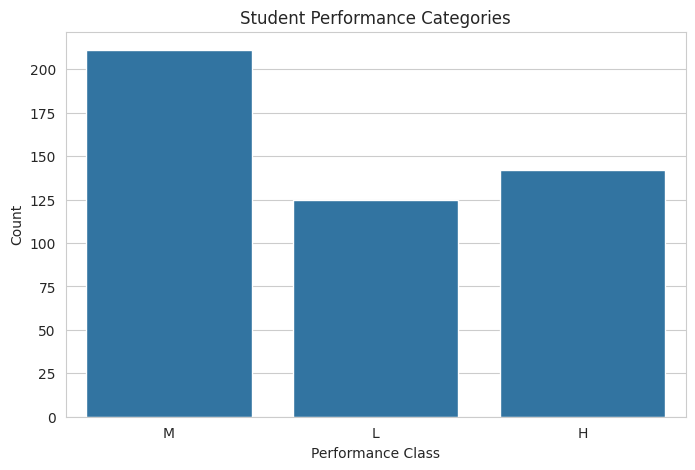

In [58]:
 # VISUALIZE TARGET CLASSES

plt.figure(figsize=(8,5))
sns.countplot(x='Class', data=df)
plt.title("Student Performance Categories")
plt.xlabel("Performance Class")
plt.ylabel("Count")
plt.show()

In [59]:
## STEP 6 : SEPARATE CATEGORICAL & NUMERICAL COLUMNS

categorical_columns = df.select_dtypes(include=['object']).columns
numerical_columns = df.select_dtypes(exclude=['object']).columns

print("Categorical Columns:\n")
print(categorical_columns)

print("\nNumerical Columns:\n")
print(numerical_columns)

Categorical Columns:

Index(['gender', 'NationalITy', 'PlaceofBirth', 'StageID', 'GradeID',
       'SectionID', 'Topic', 'Semester', 'Relation', 'ParentAnsweringSurvey',
       'ParentschoolSatisfaction', 'StudentAbsenceDays', 'Class'],
      dtype='object')

Numerical Columns:

Index(['raisedhands', 'VisITedResources', 'AnnouncementsView', 'Discussion'], dtype='object')


In [60]:
 # LABEL ENCODING

# Create LabelEncoder object
label_encoder = LabelEncoder()

# Encode categorical columns
for column in categorical_columns:
    df[column] = label_encoder.fit_transform(df[column])

# Display encoded dataset
df.head()

,gender,NationalITy,PlaceofBirth,StageID,GradeID,SectionID,Topic,Semester,Relation,raisedhands,VisITedResources,AnnouncementsView,Discussion,ParentAnsweringSurvey,ParentschoolSatisfaction,StudentAbsenceDays,Class
0,1,4,4,2,1,0,7,0,0,15,16,2,20,1,1,1,2
1,1,4,4,2,1,0,7,0,0,20,20,3,25,1,1,1,2
2,1,4,4,2,1,0,7,0,0,10,7,0,30,0,0,0,1
3,1,4,4,2,1,0,7,0,0,30,25,5,35,0,0,0,1
4,1,4,4,2,1,0,7,0,0,40,50,12,50,0,0,0,2


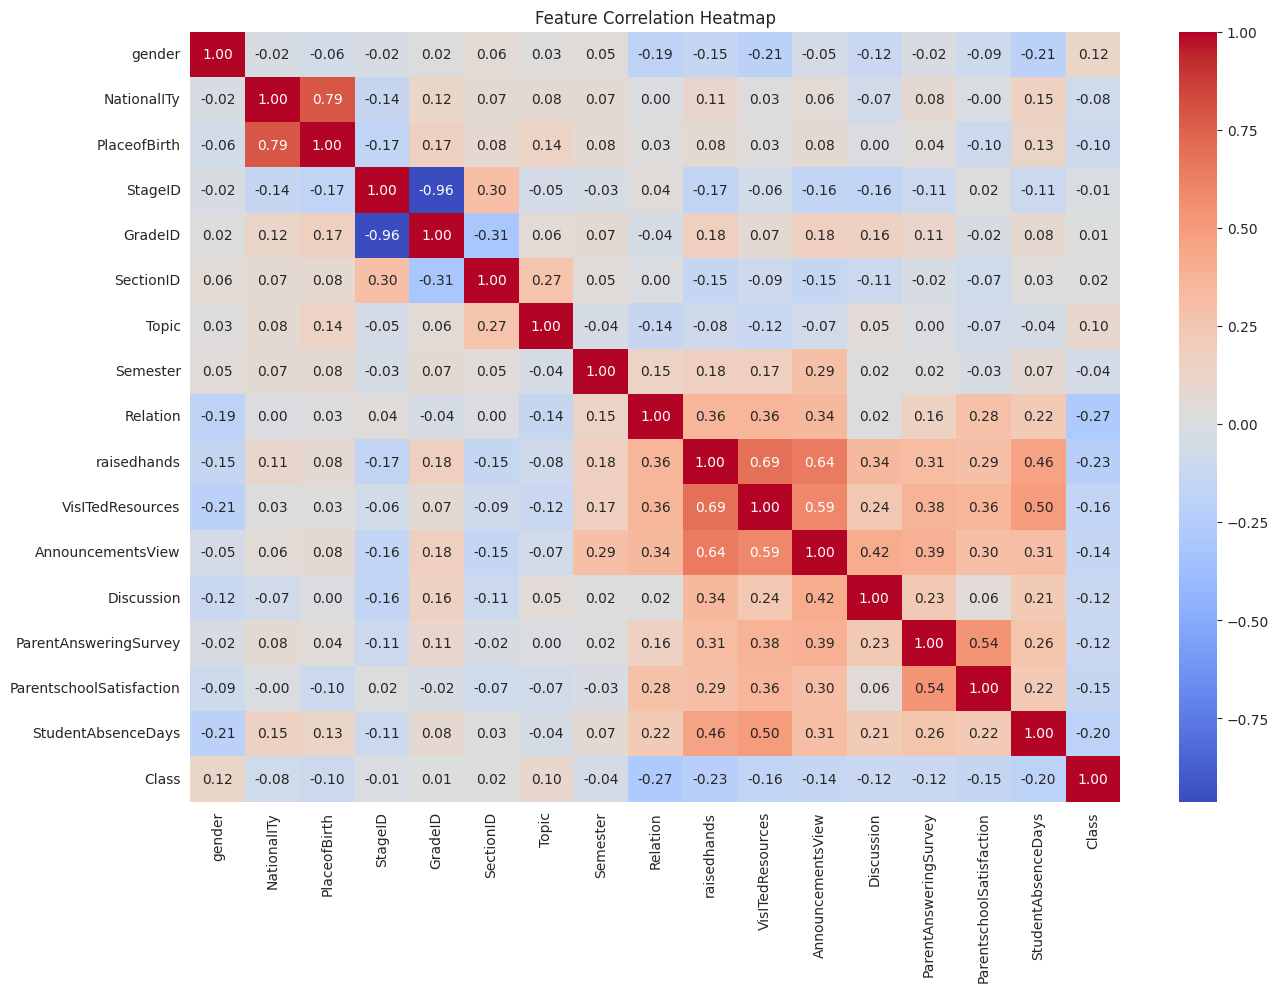

In [61]:
 # CORRELATION MATRIX

plt.figure(figsize=(15,10))
correlation_matrix = df.corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Feature Correlation Heatmap")
plt.show()

In [63]:
## STEP 7 :  DESCRIPTIVE STATISTICS (EDA)

df.describe()

,gender,NationalITy,PlaceofBirth,StageID,GradeID,SectionID,Topic,Semester,Relation,raisedhands,VisITedResources,AnnouncementsView,Discussion,ParentAnsweringSurvey,ParentschoolSatisfaction,StudentAbsenceDays,Class
count,478.000000,478.000000,478.000000,478.000000,478.000000,478.000000,478.000000,478.000000,478.000000,478.000000,478.000000,478.000000,478.000000,478.000000,478.000000,478.000000,478.000000
mean,0.633891,4.351464,4.403766,1.343096,2.918410,0.474895,5.261506,0.489540,0.412134,46.887029,54.974895,38.014644,43.410042,0.564854,0.610879,0.604603,1.144351
std,0.482244,2.472895,2.632276,0.603505,2.462217,0.612926,3.394505,0.500414,0.492735,30.787903,33.035071,26.623507,27.620961,0.496296,0.488062,0.489448,0.848034
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,3.000000,3.000000,1.000000,0.000000,0.000000,3.000000,0.000000,0.000000,16.000000,20.000000,14.250000,20.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,4.000000,4.000000,1.000000,4.000000,0.000000,5.000000,0.000000,0.000000,50.000000,65.000000,33.000000,39.500000,1.000000,1.000000,1.000000,1.000000
75%,1.000000,4.000000,4.000000,2.000000,5.000000,1.000000,7.000000,1.000000,1.000000,75.000000,84.000000,58.000000,70.000000,1.000000,1.000000,1.000000,2.000000
max,1.000000,13.000000,13.000000,2.000000,9.000000,2.000000,11.000000,1.000000,1.000000,100.000000,99.000000,98.000000,99.000000,1.000000,1.000000,1.000000,2.000000


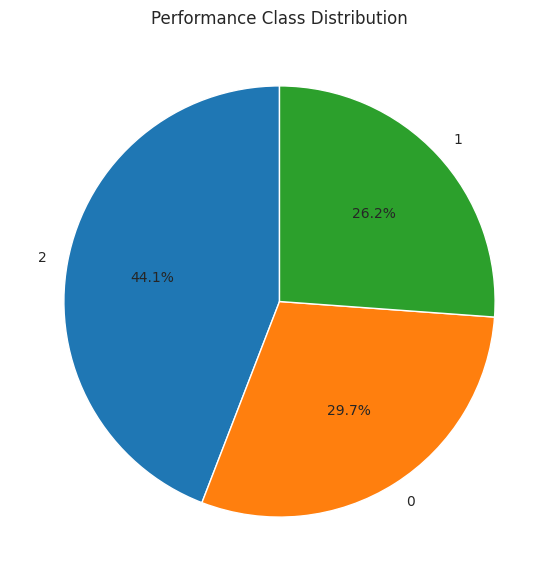

In [64]:
# PERFORMANCE CLASS DISTRIBUTION

performance_counts = df['Class'].value_counts()
plt.figure(figsize=(7,7))
plt.pie(
    performance_counts,
    labels=performance_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Performance Class Distribution")
plt.show()

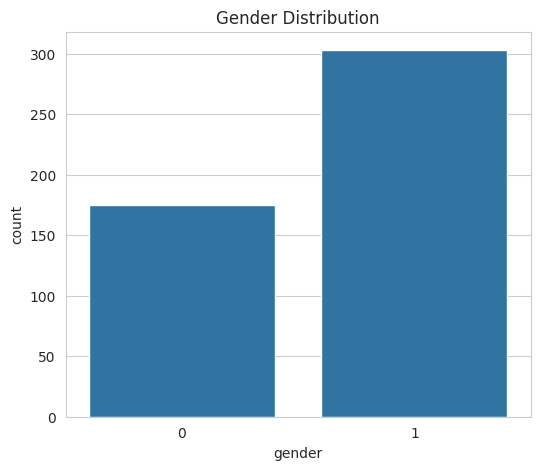

In [65]:
# STUDENT GENDER DISTRIBUTION

plt.figure(figsize=(6,5))
sns.countplot(x='gender', data=df)
plt.title("Gender Distribution")
plt.show()

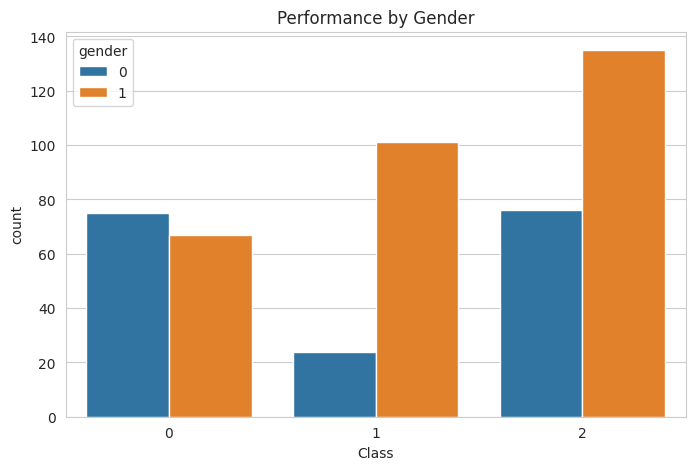

In [66]:
# PERFORMANCE VS GENDER

plt.figure(figsize=(8,5))
sns.countplot(
    x='Class',
    hue='gender',
    data=df
)

plt.title("Performance by Gender")
plt.show()

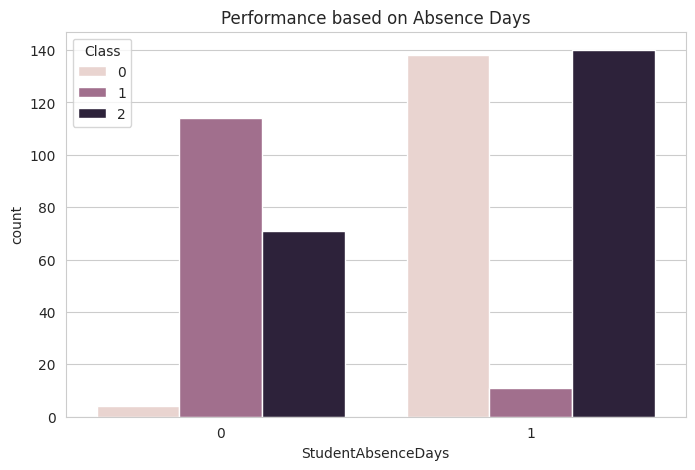

In [67]:
# PERFORMANCE VS ABSENCE DAYS

plt.figure(figsize=(8,5))
sns.countplot(
    x='StudentAbsenceDays',
    hue='Class',
    data=df
)

plt.title("Performance based on Absence Days")
plt.show()

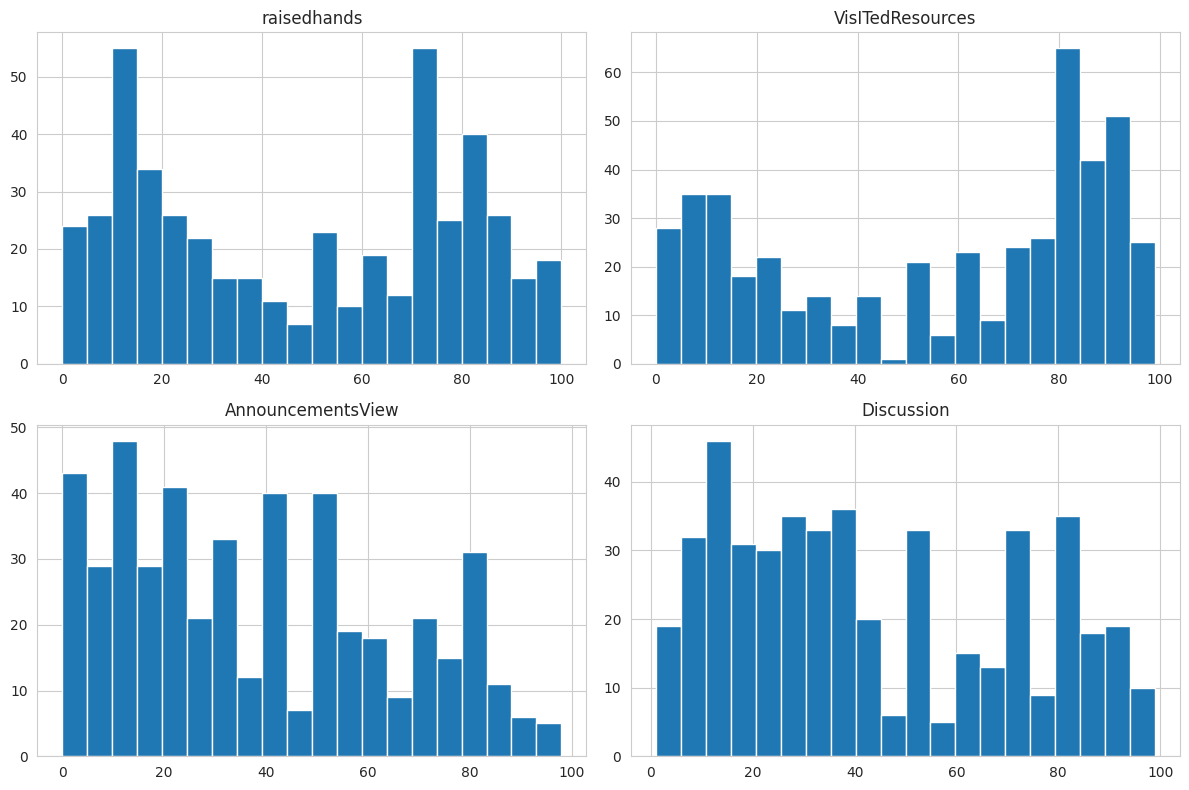

In [68]:
# DISTRIBUTION OF NUMERICAL FEATURES

df[numerical_columns].hist(
    figsize=(12,8),
    bins=20
)
plt.tight_layout()
plt.show()

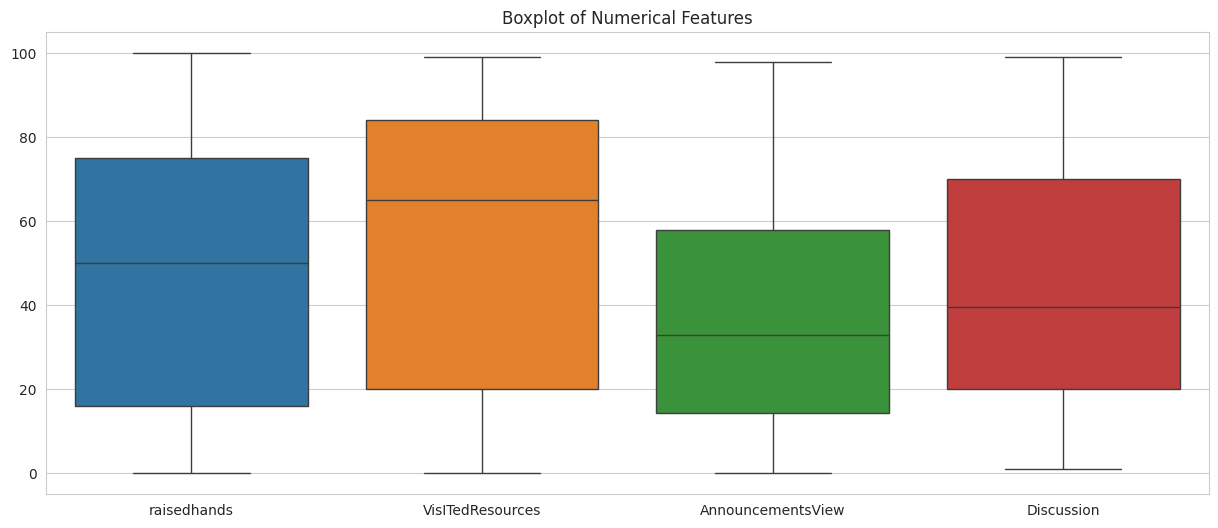

In [69]:
# BOXPLOTS FOR NUMERICAL FEATURES

plt.figure(figsize=(15,6))
sns.boxplot(data=df[numerical_columns])
plt.title("Boxplot of Numerical Features")
plt.show()

In [70]:
# CORRELATION WITH TARGET VARIABLE (FEATURE IMPORTANCE ANALYSIS PREVIEW)

target_correlation = correlation_matrix['Class'].sort_values(ascending=False)
print(target_correlation)

Class                       1.000000
gender                      0.124371
Topic                       0.103382
SectionID                   0.017070
GradeID                     0.012680
StageID                    -0.010952
Semester                   -0.043366
NationalITy                -0.078226
PlaceofBirth               -0.099419
Discussion                 -0.123091
ParentAnsweringSurvey      -0.124403
AnnouncementsView          -0.144854
ParentschoolSatisfaction   -0.147653
VisITedResources           -0.163231
StudentAbsenceDays         -0.200606
raisedhands                -0.232069
Relation                   -0.273119
Name: Class, dtype: float64


In [71]:
## MODEL BUILDING
# STEP 8 : SEPARATE FEATURES & TARGET

X = df.drop('Class', axis=1)
y = df['Class']
print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (478, 16)
Target Shape: (478,)


In [72]:
# TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)
print("y_train Shape:", y_train.shape)
print("y_test Shape:", y_test.shape)

X_train Shape: (382, 16)
X_test Shape: (96, 16)
y_train Shape: (382,)
y_test Shape: (96,)


In [73]:
# FEATURE SCALING

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Feature Scaling Completed!")

Feature Scaling Completed!


In [76]:
# MODEL 1 : LOGISTIC REGRESSION

log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)
print("Logistic Regression Model Trained Successfully!")

# PREDICTION
y_pred_log = log_model.predict(X_test_scaled)
print(y_pred_log[:10])

# EVALUATION
log_accuracy = accuracy_score(y_test, y_pred_log)
print("Logistic Regression Accuracy:", log_accuracy)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_log))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_log))

Logistic Regression Model Trained Successfully!
[2 1 2 1 1 1 0 2 2 0]
Logistic Regression Accuracy: 0.8229166666666666

Classification Report:

              precision    recall  f1-score   support

           0       0.79      0.92      0.85        24
           1       0.82      0.85      0.84        27
           2       0.85      0.76      0.80        45

    accuracy                           0.82        96
   macro avg       0.82      0.84      0.83        96
weighted avg       0.83      0.82      0.82        96


Confusion Matrix:

[[22  0  2]
 [ 0 23  4]
 [ 6  5 34]]


In [78]:
# MODEL 2 : DECISION TREE

tree_model = DecisionTreeClassifier(
    random_state=42
)
tree_model.fit(X_train, y_train)
print("Decision Tree Model Trained Successfully!")

# PREDICTION
y_pred_tree = tree_model.predict(X_test)
print(y_pred_tree[:10])

# EVALUATION
tree_accuracy = accuracy_score(y_test, y_pred_tree)
print("Decision Tree Accuracy:", tree_accuracy)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_tree))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_tree))

Decision Tree Model Trained Successfully!
[2 1 0 1 1 1 0 0 2 0]
Decision Tree Accuracy: 0.6458333333333334

Classification Report:

              precision    recall  f1-score   support

           0       0.52      0.67      0.58        24
           1       0.77      0.85      0.81        27
           2       0.66      0.51      0.57        45

    accuracy                           0.65        96
   macro avg       0.65      0.68      0.65        96
weighted avg       0.65      0.65      0.64        96


Confusion Matrix:

[[16  0  8]
 [ 0 23  4]
 [15  7 23]]


In [82]:
# MODEL 3 : RANDOM FOREST MODEL

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf_model.fit(X_train, y_train)
print("Random Forest Model Trained Successfully!")

# PREDICTION
y_pred_rf = rf_model.predict(X_test)
print(y_pred_rf[:10])

# EVALUATION
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", rf_accuracy)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Model Trained Successfully!
[2 1 2 1 1 1 0 0 2 2]
Random Forest Accuracy: 0.8229166666666666

Classification Report:

              precision    recall  f1-score   support

           0       0.74      0.83      0.78        24
           1       0.89      0.89      0.89        27
           2       0.83      0.78      0.80        45

    accuracy                           0.82        96
   macro avg       0.82      0.83      0.83        96
weighted avg       0.83      0.82      0.82        96


Confusion Matrix:

[[20  0  4]
 [ 0 24  3]
 [ 7  3 35]]


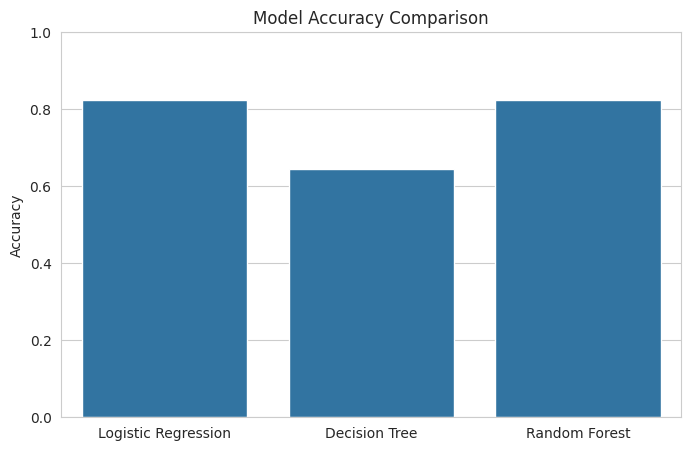

In [83]:
## STEP 9 : MODEL COMPARISON

models = ['Logistic Regression', 'Decision Tree', 'Random Forest']
accuracies = [
    log_accuracy,
    tree_accuracy,
    rf_accuracy
]
plt.figure(figsize=(8,5))
sns.barplot(
    x=models,
    y=accuracies
)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.show()

In [84]:
# FEATURE IMPORTANCE

importance = rf_model.feature_importances_
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)
print(feature_importance)

                     Feature  Importance
10          VisITedResources    0.187741
9                raisedhands    0.149936
15        StudentAbsenceDays    0.123051
11         AnnouncementsView    0.116977
12                Discussion    0.095363
6                      Topic    0.047284
13     ParentAnsweringSurvey    0.043908
4                    GradeID    0.038923
8                   Relation    0.038210
1                NationalITy    0.031806
2               PlaceofBirth    0.030650
0                     gender    0.025531
14  ParentschoolSatisfaction    0.024630
3                    StageID    0.018539
5                  SectionID    0.016202
7                   Semester    0.011250


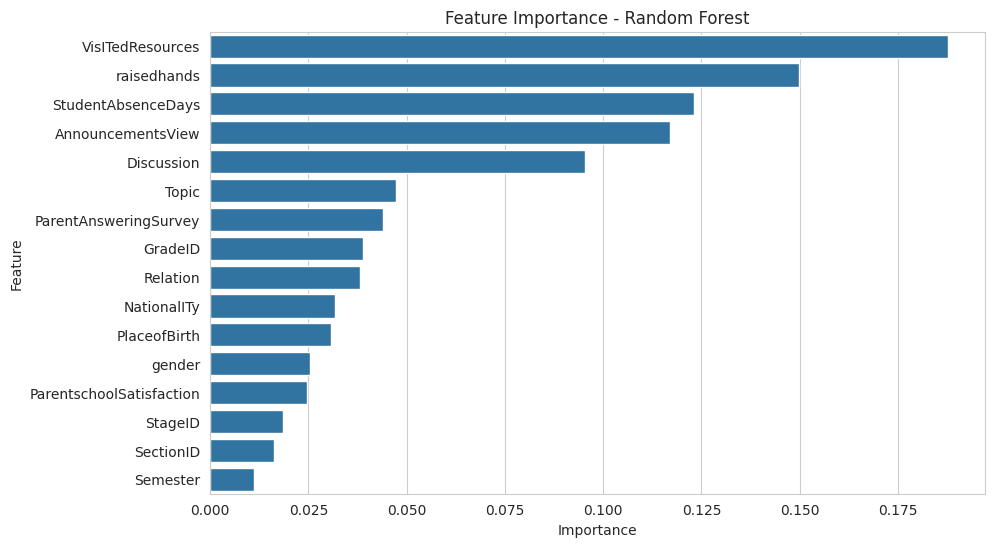

In [85]:
# FEATURE IMPORTANCE VISUALIZATION

plt.figure(figsize=(10,6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)
plt.title("Feature Importance - Random Forest")
plt.show()

In [86]:
 # SAVE TRAINED MODEL & SCALER

import joblib
joblib.dump(rf_model, 'model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("Model and Scaler Saved Successfully!")

Model and Scaler Saved Successfully!


# PROJECT CONCLUSION

This project focused on predicting student academic performance using machine learning techniques.

The dataset was preprocessed by handling duplicates, encoding categorical variables, and scaling numerical features. Exploratory Data Analysis (EDA) was performed to understand relationships between various student activities and academic performance.

Three machine learning models were implemented :-

1. Logistic Regression
2. Decision Tree Classifier
3. Random Forest Classifier

Among all models, Logistic Regression and Random Forest achieved the highest accuracy of approximately 82%.

Feature importance analysis revealed that :-
- Visiting educational resources
- Raising hands in class
- Student attendance
- Viewing announcements
- Classroom discussions

were the most influential factors affecting student performance.

The project demonstrates how machine learning can help educational institutions identify student behavior patterns and improve academic outcomes through data-driven decision making.

# FUTURE IMPROVEMENTS

Future enhancements for this project may include :-

- Using larger real-world educational datasets
- Applying advanced machine learning models such as XGBoost or Neural Networks
- Performing hyperparameter tuning for improved accuracy
- Building a web application using Flask or Streamlit
- Deploying the model for real-time student performance prediction
- Adding dashboards and interactive visualizations